# TP — Réseaux antagonistes génératifs (GAN) avec PyTorch




Les cellules marquées **`# TODO`** sont à compléter. 

> **Conseil :** exécutez ce notebook dans **Google Colab** (Fichier › Importer le notebook, puis Exécution › Modifier le type d'exécution › GPU). Il fonctionne aussi sur CPU, en un peu plus de temps.

## Rappel : le principe d'un GAN

- Le **générateur** $G$ reçoit un bruit aléatoire $z \sim \mathcal{N}(0, I)$ et produit un faux échantillon $G(z)$.
- Le **discriminateur** $D$ reçoit un échantillon et renvoie la probabilité $D(x)$ qu'il soit **réel**.

Les deux réseaux jouent un jeu à somme nulle :

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{\text{data}}}\big[\log D(x)\big] + \mathbb{E}_{z \sim p_z}\big[\log\big(1 - D(G(z))\big)\big]$$

En pratique, on alterne à chaque itération :
1. **Étape D** : on entraîne $D$ à répondre 1 sur les vrais échantillons et 0 sur les faux.
2. **Étape G** : on entraîne $G$ à ce que $D$ réponde 1 sur ses faux échantillons.

Les deux étapes s'écrivent avec la **binary cross-entropy** : $\text{BCE}(p, y) = -\big[y \log p + (1-y)\log(1-p)\big]$.

---
# Partie 0 — Mise en place
Sur Colab, tout est déjà installé. En local : `pip install torch torchvision matplotlib`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| device :", device)

PyTorch 2.14.1+cpu | device : cpu


---
# Partie 1 — Échauffement : un GAN en 1 dimension

On veut que $G$ apprenne à imiter une loi très simple : une **gaussienne de moyenne 4 et d'écart-type 1,25**.
$G$ ne voit jamais les vraies données ; il n'apprend qu'à travers le jugement de $D$.

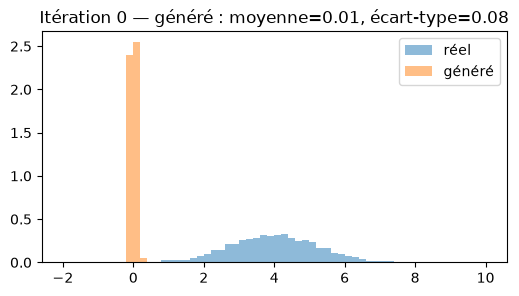

In [3]:
REAL_MEAN, REAL_STD = 4.0, 1.25
NOISE_DIM_1D = 8

def sample_real(n):
    # Vrais échantillons : N(4, 1.25²), forme (n, 1)
    return torch.randn(n, 1) * REAL_STD + REAL_MEAN

def sample_noise_1d(n):
    # Bruit d'entrée du générateur, forme (n, NOISE_DIM_1D)
    return torch.randn(n, NOISE_DIM_1D)

G1 = nn.Sequential(
    nn.Linear(NOISE_DIM_1D, 32), nn.ReLU(),
    nn.Linear(32, 32), nn.ReLU(),
    nn.Linear(32, 1),
)
D1 = nn.Sequential(
    nn.Linear(1, 32), nn.LeakyReLU(0.2),
    nn.Linear(32, 32), nn.LeakyReLU(0.2),
    nn.Linear(32, 1),            # pas de sigmoïde : on renvoie un « logit »
)

criterion = nn.BCEWithLogitsLoss()   # = sigmoïde + BCE, plus stable numériquement
opt_G1 = torch.optim.Adam(G1.parameters(), lr=1e-3, betas=(0.5, 0.999))
opt_D1 = torch.optim.Adam(D1.parameters(), lr=1e-3, betas=(0.5, 0.999))

def show_1d(step):
    with torch.no_grad():
        fake = G1(sample_noise_1d(5000)).squeeze().numpy()
    real = sample_real(5000).squeeze().numpy()
    plt.figure(figsize=(6, 3))
    plt.hist(real, bins=60, range=(-2, 10), alpha=0.5, density=True, label="réel")
    plt.hist(fake, bins=60, range=(-2, 10), alpha=0.5, density=True, label="généré")
    plt.title(f"Itération {step} — généré : moyenne={fake.mean():.2f}, écart-type={fake.std():.2f}")
    plt.legend(); plt.show()

show_1d(0)   # avant entraînement

### À faire : l'étape d'entraînement
Complétez `train_step_1d`. Elle doit :
1. **Étape D** : calculer la perte de $D$ sur un lot de vrais échantillons (étiquette 1) et un lot de faux (étiquette 0), puis faire un pas d'optimisation de $D$.
2. **Étape G** : générer un nouveau lot de faux, calculer la perte de $G$ **en utilisant l'étiquette 1**, puis faire un pas d'optimisation de $G$.

Rappel PyTorch : `optimiseur.zero_grad()`, `perte.backward()`, `optimiseur.step()`.

In [4]:
def train_step_1d(batch_size=128):
    ones = torch.ones(batch_size, 1)
    zeros = torch.zeros(batch_size, 1)

    # ---------- Étape D ----------
    real = sample_real(batch_size)
    fake = G1(sample_noise_1d(batch_size)).detach()
    d_loss = criterion(D1(real), ones) + criterion(D1(fake), zeros)
    opt_D1.zero_grad()
    d_loss.backward()
    opt_D1.step()

    # ---------- Étape G ----------
    fake = G1(sample_noise_1d(batch_size))
    g_loss = criterion(D1(fake), ones)
    opt_G1.zero_grad()
    g_loss.backward()
    opt_G1.step()

    return d_loss.item(), g_loss.item()

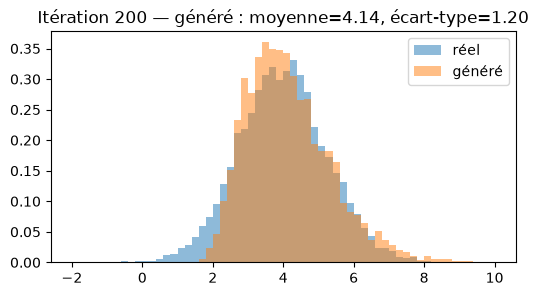

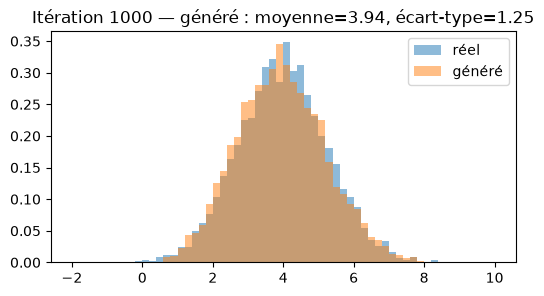

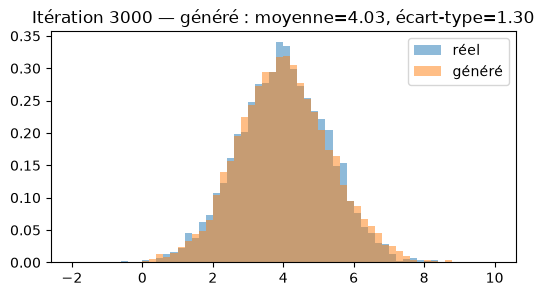

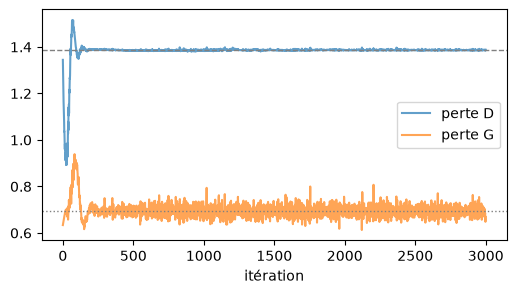

In [5]:
N_STEPS_1D = 3000
hist_d, hist_g = [], []
for step in range(1, N_STEPS_1D + 1):
    d, g = train_step_1d()
    hist_d.append(d); hist_g.append(g)
    if step in (200, 1000, N_STEPS_1D):
        show_1d(step)

plt.figure(figsize=(6, 3))
plt.plot(hist_d, label="perte D", alpha=0.7)
plt.plot(hist_g, label="perte G", alpha=0.7)
plt.axhline(2 * np.log(2), ls="--", c="gray", lw=1)
plt.axhline(np.log(2), ls=":", c="gray", lw=1)
plt.xlabel("itération"); plt.legend(); plt.show()

*Indications :*

- **Q1.** `.detach()` coupe le graphe de calcul entre le générateur et les faux échantillons. Pendant l'étape D, le gradient met ainsi à jour uniquement le discriminateur, sans entraîner G.
- **Q2.** À cette étape, G veut tromper D : il cherche donc à faire classer ses faux échantillons comme réels. L'étiquette cible est 1, ce qui fournit à G un gradient qui l'encourage à produire des échantillons plus réalistes.
- **Q3.** Oui. À 200 itérations, on observe une moyenne de 4,14 et un écart-type de 1,20 ; à 1 000, environ 3,94 et 1,25 ; à 3 000, environ 4,03 et 1,30. Dans cette exécution, l'écart-type semble converger un peu plus vite, mais les deux valeurs fluctuent et deviennent rapidement proches des cibles 4 et 1,25.
- **Q4.** Avec $D(x)=0{,}5$, la BCE vaut $-\ln(0{,}5)=\ln 2$ pour chaque lot. Comme la perte de D additionne le terme réel et le terme faux, $L_D=2\ln 2\approx1{,}386$. Pour G, $L_G=\ln 2\approx0{,}693$. Ces valeurs correspondent aux lignes pointillées du graphique.

---
# Partie 2 — Un GAN qui génère des chiffres (MNIST)

## 2.1 Les données
Les images MNIST font 28×28 pixels en niveaux de gris. On les normalise dans **[-1, 1]**.

100%|██████████| 9.91M/9.91M [00:12<00:00, 770kB/s] 
100%|██████████| 28.9k/28.9k [00:00<00:00, 198kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.79MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.04MB/s]


Forme d'un lot : (128, 1, 28, 28) | min = -1.0 | max = 1.0


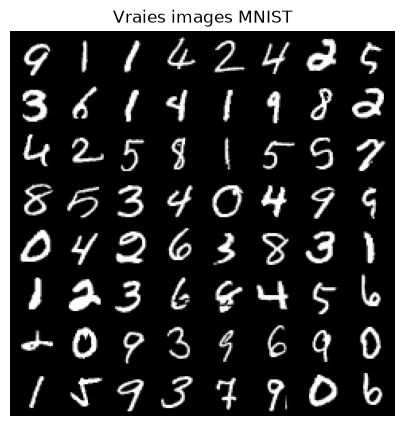

In [6]:
BATCH_SIZE = 128

transform = transforms.Compose([
    transforms.ToTensor(),                  # [0, 255] -> [0, 1]
    transforms.Normalize((0.5,), (0.5,)),   # [0, 1]   -> [-1, 1]
])
train_set = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

def show_images(images, nrow=8, title=None):
    grid = make_grid(images.detach().cpu()[:nrow * nrow], nrow=nrow, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(5, 5)); plt.imshow(grid.permute(1, 2, 0)); plt.axis("off")
    if title: plt.title(title)
    plt.show()

images, labels = next(iter(loader))
print("Forme d'un lot :", tuple(images.shape), "| min =", images.min().item(), "| max =", images.max().item())
show_images(images, title="Vraies images MNIST")

## 2.2 Le générateur
Complétez le générateur : un perceptron multicouche qui transforme $z \in \mathbb{R}^{100}$ en une image de $28 \times 28 = 784$ pixels.

Architecture demandée :
`Linear(100→256)` → `LeakyReLU(0.2)` → `Linear(256→512)` → `LeakyReLU(0.2)` → `Linear(512→1024)` → `LeakyReLU(0.2)` → `Linear(1024→784)` → **`Tanh`**

In [ ]:
LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 28 * 28), nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z).view(z.size(0), 1, 28, 28)

## 2.3 Le discriminateur
Architecture demandée (sortie = **un logit**, sans sigmoïde, car on utilise `BCEWithLogitsLoss`) :
`Flatten` → `Linear(784→512)` → `LeakyReLU(0.2)` → `Dropout(0.3)` → `Linear(512→256)` → `LeakyReLU(0.2)` → `Dropout(0.3)` → `Linear(256→1)`

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x)

**Vérification** — exécutez cette cellule : elle doit afficher `Tout est correct` sans erreur.

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

z = torch.randn(16, LATENT_DIM, device=device)
x_fake = G(z)
assert x_fake.shape == (16, 1, 28, 28), f"Sortie de G : {tuple(x_fake.shape)} au lieu de (16, 1, 28, 28)"
assert x_fake.min() >= -1 and x_fake.max() <= 1, "Les pixels générés doivent être dans [-1, 1]"
assert D(x_fake).shape == (16, 1), f"Sortie de D : {tuple(D(x_fake).shape)} au lieu de (16, 1)"
n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"Paramètres : G = {n_params(G):,} | D = {n_params(D):,}")
print("Tout est correct")

### Questions — architecture
- **Q5.** Pourquoi le générateur se termine-t-il par `Tanh` ? Quel lien avec la normalisation des données ?
- **Q6.** Pourquoi utiliser `LeakyReLU` plutôt que `ReLU` dans le discriminateur ?

*Vos réponses :*

- **Q5.** `Tanh` borne la sortie du générateur dans `[-1, 1]`. C'est cohérent avec les images MNIST, normalisées dans le même intervalle par `Normalize((0.5,), (0.5,))` : le générateur peut ainsi produire des pixels sur la même échelle que les données réelles.
- **Q6.** `LeakyReLU` conserve un petit gradient pour les valeurs négatives, contrairement à `ReLU` qui renvoie zéro et peut bloquer durablement certains neurones. Le discriminateur continue ainsi à apprendre et à transmettre un gradient utile au générateur.

## 2.4 La boucle d'entraînement
Complétez `train_step`. C'est **exactement** la même logique qu'en partie 1, avec des images.
On renvoie aussi $\overline{D(x)}$ et $\overline{D(G(z))}$ (moyennes des probabilités, après sigmoïde) pour suivre le jeu.

In [ ]:
LR = 2e-4
criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

In [ ]:
def train_step(real):
    real = real.to(device)
    b = real.size(0)
    ones = torch.ones(b, 1, device=device)
    zeros = torch.zeros(b, 1, device=device)

    # ---------- Étape D ----------
    z = torch.randn(b, LATENT_DIM, device=device)
    fake = G(z)
    out_real = D(real)
    out_fake = D(fake.detach())
    d_loss = criterion(out_real, ones) + criterion(out_fake, zeros)
    opt_D.zero_grad()
    d_loss.backward()
    opt_D.step()

    # ---------- Étape G ----------
    g_loss = criterion(D(fake), ones)
    opt_G.zero_grad()
    g_loss.backward()
    opt_G.step()

    d_real = torch.sigmoid(out_real).mean().item()   # D(x)    : proba « réel » sur les vraies images
    d_fake = torch.sigmoid(out_fake).mean().item()   # D(G(z)) : proba « réel » sur les fausses
    return d_loss.item(), g_loss.item(), d_real, d_fake

Lancez l'entraînement. On génère toujours les images à partir du **même bruit fixe** `fixed_z`, pour voir l'évolution.
Durée indicative : ~10 s par époque sur GPU, ~30–60 s sur CPU. Commencez avec `EPOCHS = 20`.

In [ ]:
EPOCHS = 20
fixed_z = torch.randn(64, LATENT_DIM, device=device)
history = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    for real, _ in loader:
        d_loss, g_loss, d_real, d_fake = train_step(real)
        for k, v in zip(history, (d_loss, g_loss, d_real, d_fake)):
            history[k].append(v)
    print(f"Époque {epoch:2d}/{EPOCHS} | perte D = {d_loss:.3f} | perte G = {g_loss:.3f} "
          f"| D(x) = {d_real:.2f} | D(G(z)) = {d_fake:.2f}")
    if epoch in (1, 5, 10) or epoch == EPOCHS:
        G.eval()
        with torch.no_grad():
            show_images(G(fixed_z), title=f"Images générées — époque {epoch}")

torch.save(G.state_dict(), "generateur_mnist.pt")

In [ ]:
def smooth(x, k=50):
    return np.convolve(x, np.ones(k) / k, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(smooth(history["d_loss"]), label="perte D")
axes[0].plot(smooth(history["g_loss"]), label="perte G")
axes[0].set_xlabel("itération"); axes[0].set_title("Pertes (moyenne glissante)"); axes[0].legend()
axes[1].plot(smooth(history["d_real"]), label="D(x) — vraies images")
axes[1].plot(smooth(history["d_fake"]), label="D(G(z)) — images générées")
axes[1].axhline(0.5, ls="--", c="gray", lw=1)
axes[1].set_xlabel("itération"); axes[1].set_title("Sorties du discriminateur"); axes[1].legend()
plt.show()

### Questions — entraînement
- **Q7.** Décrivez l'évolution des images générées entre l'époque 1 et la dernière. Les chiffres sont-ils reconnaissables ? Tous les chiffres de 0 à 9 apparaissent-ils ?
- **Q8.** La perte de $G$ **augmente**-t-elle ou **diminue**-t-elle au cours de l'entraînement ? Peut-on s'en servir pour savoir si le GAN « s'améliore » ? Justifiez.
- **Q9.** Que valent $D(x)$ et $D(G(z))$ en fin d'entraînement ? Qui « gagne » le jeu ?

*Vos réponses :*

- **Q7.** À l'époque 1, les images ressemblent surtout à du bruit. Elles deviennent progressivement plus structurées et plusieurs chiffres sont reconnaissables à la dernière époque, même s'ils restent flous et imparfaits. La grille montre plusieurs formes et des répétitions; elle ne permet pas d'affirmer que les dix chiffres sont tous générés nettement ni de façon équilibrée.
- **Q8.** La perte de G diminue globalement dans cette exécution (d'environ 1,44 à l'époque 1 à 0,96 à l'époque 20), mais elle fluctue fortement entre les époques. On ne peut pas juger seul de l'amélioration du GAN à partir de cette perte : G et D évoluent ensemble, et une baisse peut refléter l'état momentané de leur compétition plutôt que la qualité ou la diversité des images. Il faut aussi examiner les images et les sorties de D.
- **Q9.** À la dernière époque, pour le dernier lot traité, on mesure environ $D(x)=0{,}53$ et $D(G(z))=0{,}39$. D donne une probabilité un peu plus élevée aux vraies images qu'aux fausses; il semble donc garder un léger avantage, mais le résultat n'indique pas un vainqueur définitif.

---
# Partie 3 — Analyse et expériences

## 3.1 Interpolation dans l'espace latent (obligatoire)
Choisissez deux bruits $z_1$ et $z_2$ et générez les images de $z_\alpha = (1-\alpha)\,z_1 + \alpha\,z_2$ pour 10 valeurs de $\alpha$ entre 0 et 1.

In [ ]:
G.eval()
z1 = torch.randn(1, LATENT_DIM, device=device)
z2 = torch.randn(1, LATENT_DIM, device=device)
alphas = torch.linspace(0, 1, 10, device=device).view(-1, 1)

z_interp = (1 - alphas) * z1 + alphas * z2
with torch.no_grad():
    images_interp = G(z_interp)

grid = make_grid(images_interp.cpu(), nrow=10, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 2)); plt.imshow(grid.permute(1, 2, 0)); plt.axis("off"); plt.show()

- **Q10.** La transition est-elle continue ? Que peut-on en conclure sur ce qu'a appris le générateur (a-t-il simplement mémorisé des images d'entraînement) ?

*Vos réponses :*

- **Q10.** Les pixels évoluent progressivement le long de l'interpolation, comme attendu puisque le générateur est une fonction continue de $z$. Dans cette exécution, les images restent toutefois très bruitées et aucun changement de chiffre clairement reconnaissable ne se dégage. L'interpolation est compatible avec un espace latent continu, mais ne suffit pas à prouver que G n'a pas mémorisé des exemples ; il faudrait aussi comparer les images générées aux données d'entraînement, par exemple avec leurs plus proches voisins.

## 3.2 Expériences (choisissez-en **deux**)
Pour chaque expérience, **réinitialisez** les modèles avec la cellule ci-dessous, modifiez **un seul** paramètre, relancez l'entraînement (5 à 10 époques suffisent) et comparez images et courbes à la référence.

| # | Modification | Ce qu'on cherche à observer |
|---|---|---|
| E1 | Taux d'apprentissage de $D$ multiplié par 10 (`opt_D` avec `lr=2e-3`) | Déséquilibre : que se passe-t-il quand $D$ est trop fort ? |
| E2 | Perte « saturante » pour $G$ : remplacer `g_loss` par `-criterion(D(fake), zeros)` | Le problème du gradient qui s'annule au début de l'entraînement |
| E3 | *Label smoothing* : cibles réelles à 0,9 au lieu de 1 dans l'étape D | Régularisation de $D$ |
| E4 | `LATENT_DIM = 2` | Que peut encoder un espace latent si petit ? |

- **Q11.** Pour chacune de vos deux expériences : décrivez ce que vous observez (images + courbes) et proposez une explication.

In [ ]:
# Cellule de réinitialisation : à exécuter avant chaque expérience
torch.manual_seed(0)
G = Generator().to(device)
D = Discriminator().to(device)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))
fixed_z = torch.randn(64, LATENT_DIM, device=device)
history = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}
# Modifiez ici (ou dans train_step), puis relancez la cellule d'entraînement avec EPOCHS = 5 à 10.

In [ ]:
# E1 — taux d'apprentissage de D multiplié par 10
# Garde les mêmes poids initiaux et le même bruit fixe pour faciliter la comparaison.
torch.manual_seed(0)
G = Generator().to(device)
D = Discriminator().to(device)
fixed_z_e1 = torch.randn(64, LATENT_DIM, device=device)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-3, betas=(0.5, 0.999))

EPOCHS_E1 = 5
history_e1 = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}
for epoch in range(1, EPOCHS_E1 + 1):
    G.train(); D.train()
    epoch_values = {key: [] for key in history_e1}
    for real, _ in loader:
        values = train_step(real)
        for key, value in zip(history_e1, values):
            epoch_values[key].append(value)
    for key in history_e1:
        history_e1[key].append(float(np.mean(epoch_values[key])))
    print(f"E1 — époque {epoch}/{EPOCHS_E1} | D = {history_e1['d_loss'][-1]:.3f} | G = {history_e1['g_loss'][-1]:.3f} | D(x) = {history_e1['d_real'][-1]:.2f} | D(G(z)) = {history_e1['d_fake'][-1]:.2f}")
    if epoch in (1, EPOCHS_E1):
        G.eval()
        with torch.no_grad():
            show_images(G(fixed_z_e1), title=f"E1 — images générées, époque {epoch}")

G.eval(); D.eval()
real_test, _ = next(iter(loader))
with torch.no_grad():
    fake_test = G(fixed_z_e1)
    test_d_real = torch.sigmoid(D(real_test.to(device))).mean().item()
    test_d_fake = torch.sigmoid(D(fake_test)).mean().item()
print(f"E1 — test final : D(x) = {test_d_real:.3f} | D(G(z)) = {test_d_fake:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(range(1, EPOCHS_E1 + 1), history_e1["d_loss"], marker="o", label="perte D")
axes[0].plot(range(1, EPOCHS_E1 + 1), history_e1["g_loss"], marker="o", label="perte G")
axes[0].set_xlabel("époque"); axes[0].set_title("E1 — pertes"); axes[0].legend()
axes[1].plot(range(1, EPOCHS_E1 + 1), history_e1["d_real"], marker="o", label="D(x)")
axes[1].plot(range(1, EPOCHS_E1 + 1), history_e1["d_fake"], marker="o", label="D(G(z))")
axes[1].axhline(0.5, ls="--", c="gray", lw=1)
axes[1].set_xlabel("époque"); axes[1].set_title("E1 — probabilités de D"); axes[1].legend()
plt.show()

In [ ]:
# E2 — perte saturante pour le générateur
# Le générateur minimise -BCE(D(G(z)), 0), comme dans l'énoncé.
torch.manual_seed(0)
G = Generator().to(device)
D = Discriminator().to(device)
fixed_z_e2 = torch.randn(64, LATENT_DIM, device=device)
opt_G = torch.optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))


def train_step_e2(real):
    real = real.to(device)
    b = real.size(0)
    ones = torch.ones(b, 1, device=device)
    zeros = torch.zeros(b, 1, device=device)

    z = torch.randn(b, LATENT_DIM, device=device)
    fake = G(z)
    out_real = D(real)
    out_fake = D(fake.detach())
    d_loss = criterion(out_real, ones) + criterion(out_fake, zeros)
    opt_D.zero_grad()
    d_loss.backward()
    opt_D.step()

    g_loss = -criterion(D(fake), zeros)
    opt_G.zero_grad()
    g_loss.backward()
    opt_G.step()

    d_real = torch.sigmoid(out_real).mean().item()
    d_fake = torch.sigmoid(out_fake).mean().item()
    return d_loss.item(), g_loss.item(), d_real, d_fake


EPOCHS_E2 = 5
history_e2 = {"d_loss": [], "g_loss": [], "d_real": [], "d_fake": []}
for epoch in range(1, EPOCHS_E2 + 1):
    G.train(); D.train()
    epoch_values = {key: [] for key in history_e2}
    for real, _ in loader:
        values = train_step_e2(real)
        for key, value in zip(history_e2, values):
            epoch_values[key].append(value)
    for key in history_e2:
        history_e2[key].append(float(np.mean(epoch_values[key])))
    print(f"E2 — époque {epoch}/{EPOCHS_E2} | D = {history_e2['d_loss'][-1]:.3f} | G = {history_e2['g_loss'][-1]:.3f} | D(x) = {history_e2['d_real'][-1]:.2f} | D(G(z)) = {history_e2['d_fake'][-1]:.2f}")
    if epoch in (1, EPOCHS_E2):
        G.eval()
        with torch.no_grad():
            show_images(G(fixed_z_e2), title=f"E2 — images générées, époque {epoch}")

G.eval(); D.eval()
real_test, _ = next(iter(loader))
with torch.no_grad():
    fake_test = G(fixed_z_e2)
    test_d_real = torch.sigmoid(D(real_test.to(device))).mean().item()
    test_d_fake = torch.sigmoid(D(fake_test)).mean().item()
print(f"E2 — test final : D(x) = {test_d_real:.3f} | D(G(z)) = {test_d_fake:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(range(1, EPOCHS_E2 + 1), history_e2["d_loss"], marker="o", label="perte D")
axes[0].plot(range(1, EPOCHS_E2 + 1), history_e2["g_loss"], marker="o", label="perte G saturante")
axes[0].set_xlabel("époque"); axes[0].set_title("E2 — pertes"); axes[0].legend()
axes[1].plot(range(1, EPOCHS_E2 + 1), history_e2["d_real"], marker="o", label="D(x)")
axes[1].plot(range(1, EPOCHS_E2 + 1), history_e2["d_fake"], marker="o", label="D(G(z))")
axes[1].axhline(0.5, ls="--", c="gray", lw=1)
axes[1].set_xlabel("époque"); axes[1].set_title("E2 — probabilités de D"); axes[1].legend()
plt.show()

*Vos réponses :*

**Expériences réalisées : E1 et E2, cinq époques chacune.** Les images affichées dans les cellules précédentes montrent les époques 1 et 5; les courbes donnent les moyennes des lots de chaque époque.

- **E1 — taux d'apprentissage de D multiplié par 10.** La perte de D baisse de 1,000 à 0,892, tandis que celle de G augmente de 1,264 à 1,773 (avec un pic à 1,834). $D(G(z))$ moyen diminue de 0,42 à 0,29; sur le lot de test, $D(x)=0,831$ et $D(G(z))=0,263$. D prend donc nettement l'avantage. À l'époque 5, quelques chiffres sont discernables, mais les images restent très contrastées, bruitées et imparfaites. Le taux d'apprentissage élevé permet à D de s'adapter plus vite que G et rend leur compétition déséquilibrée.
- **E2 — perte saturante pour G.** La perte de D passe de 1,065 à 0,614 avec des fluctuations. La perte saturante de G est négative par définition et varie ici de $-0,455$ à $-0,158$; elle ne se compare donc pas directement à la perte positive de la méthode de référence. $D(G(z))$ moyen chute de 0,46 à 0,20; sur le lot de test, $D(x)=0,818$ et $D(G(z))=0,189$. Les images de l'époque 5 restent bruitées et présentent des formes répétitives, souvent des traits peu lisibles. Comme D rejette les faux échantillons avec une forte confiance, le gradient de la perte saturante transmis à G est faible : G progresse difficilement. Ces résultats illustrent le problème du gradient qui s'annule.